In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

I am loading in the file, and doing quick inspection to get familiar with the data.

In [2]:
data = pd.read_csv("data/raw/housing.csv")

In [3]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB


In [4]:
print("Total number of rows: " + str(data.size))

Total number of rows: 206400


In [5]:
data.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


## Splitting dataset into training and test set

In [6]:

train_set, test_set = train_test_split(data, test_size=0.2, random_state=142)

In [7]:
train_set.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,16512.000000,16512.000000,16512.000000,16512.000000,16349.000000,16512.000000,16512.000000,16512.000000,16512.000000
mean,-119.576060,35.639528,28.660792,2650.587694,540.908435,1431.202519,502.041606,3.874176,207096.552447
std,2.002628,2.133772,12.614448,2215.597732,429.925960,1155.299540,389.803155,1.897529,115463.056370
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.940000,18.000000,1451.000000,297.000000,788.000000,281.000000,2.566950,119475.000000
50%,-118.510000,34.260000,29.000000,2136.000000,435.000000,1166.500000,410.000000,3.537500,180400.000000
75%,-118.010000,37.710000,37.000000,3152.250000,646.000000,1725.250000,603.000000,4.740400,265300.000000
max,-114.310000,41.950000,52.000000,37937.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [8]:
print("Missing Values per column:")
missing_values = pd.DataFrame({
    'Missing_Count': train_set.isnull().sum(),
    'Missing_%': (train_set.isnull().mean() * 100).round(2)
})

missing_columns = missing_values[missing_values['Missing_Count'] > 0]
print(missing_columns)

Missing Values per column:
                Missing_Count  Missing_%
total_bedrooms            163       0.99


Column total_bedrooms in training set contains 163 missing values, which is around 1% of all values in this column.

<Figure size 1000x1000 with 0 Axes>

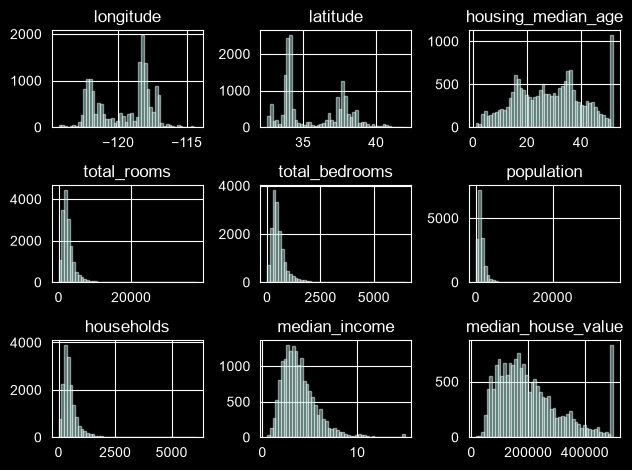

In [9]:
plt.figure(figsize=(10,10))
train_set.hist(alpha=0.5, bins=50)
plt.tight_layout()

## Handling total_bedrooms (skewness, missing values)

<Axes: >

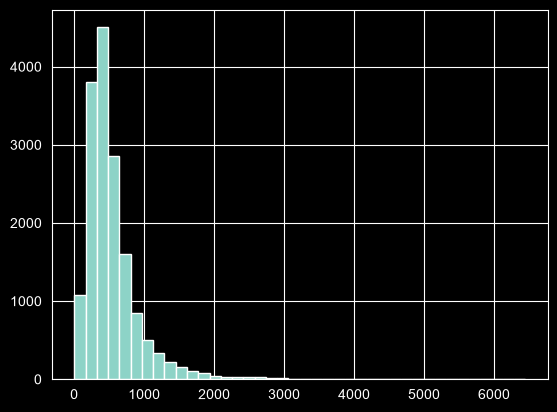

In [10]:
train_set['total_bedrooms'].hist(bins=40)

In [11]:
train_set.isna().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        163
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

<Axes: >

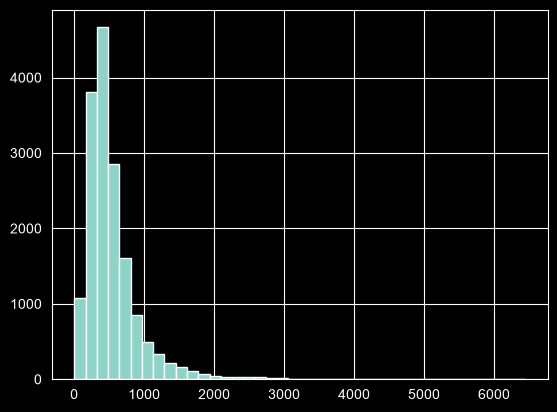

In [12]:
bedrooms_median_val = train_set['total_bedrooms'].median()
train_set.fillna({'total_bedrooms': bedrooms_median_val}, inplace=True)
train_set['total_bedrooms'].hist(bins=40)

In [13]:
q1, q3 = train_set['total_bedrooms'].quantile([0.25, 0.75])
iqr = q3 - q1
outliers = train_set[(train_set['total_bedrooms'] < q1 - 1.5 * iqr) | (train_set['total_bedrooms'] > q3 + 1.5 * iqr)]
print(f"Outlier count: {len(outliers)}")

Outlier count: 1078


In [14]:
invalid_rooms = train_set[train_set['total_bedrooms'] > train_set['total_rooms']]
print("Bedrooms > Total rooms count:", len(invalid_rooms))

Bedrooms > Total rooms count: 4


In [15]:
train_set_temp = train_set[train_set['total_bedrooms'] > train_set['total_rooms']].copy()
train_set_temp.head(6)
train_set = train_set[train_set['total_bedrooms'] <= train_set['total_rooms']].copy()

3.54372277271573
-0.9701971644338786


<Axes: >

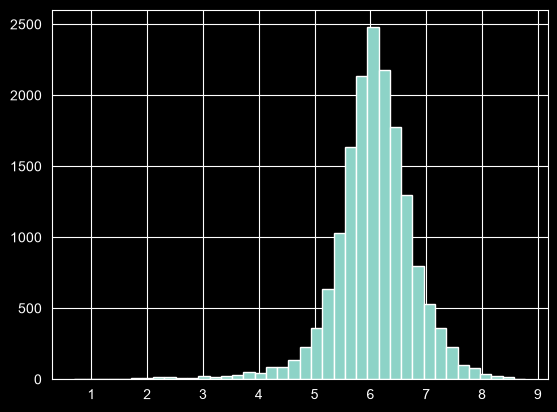

In [16]:
print(train_set['total_bedrooms'].skew())
train_set['log_total_bedrooms'] = np.log1p(train_set['total_bedrooms'])
print(train_set['log_total_bedrooms'].skew())

train_set['log_total_bedrooms'].hist(bins=40)

In [17]:
from sklearn.preprocessing import power_transform
train_set['yeo_total_bedrooms'] = power_transform(pd.DataFrame(train_set['total_bedrooms']),method='yeo-johnson',standardize=True)
print(train_set['yeo_total_bedrooms'].skew())

0.10799613570704916


<Axes: >

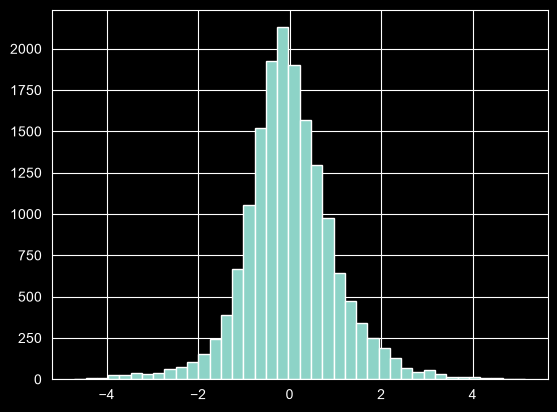

In [18]:
train_set['yeo_total_bedrooms'].hist(bins=40)

In [19]:
train_set['yeo_total_bedrooms'].kurtosis()
train_set['yeo_total_bedrooms'].describe()

count    1.650800e+04
mean     2.668624e-17
std      1.000030e+00
min     -4.706623e+00
25%     -5.701942e-01
50%     -4.829623e-02
75%      5.362626e-01
max      5.148011e+00
Name: yeo_total_bedrooms, dtype: float64

In [20]:
q1, q3 = train_set['yeo_total_bedrooms'].quantile([0.25, 0.75])
iqr = q3 - q1
outliers = train_set[(train_set['yeo_total_bedrooms'] < q1 - 1.5 * iqr) | (train_set['yeo_total_bedrooms'] > q3 + 1.5 * iqr)]
print(f"Outlier count: {len(outliers)}")

Outlier count: 705


# Target variable: median_house_price

